# 05 Error Analysis
**MSB7216: Deep Learning for Health Data | Retinal Disease Classification**

This notebook covers:
1. Load all four model results
2. Clinical cost matrix: construction and justification
3. Clinical cost scoring across all runs
4. Cross-run error pattern analysis
5. Failure case review: worst misclassifications from best model
6. Final results table
7. Commit and push

The best model identified in Notebook 03 is **ConvNeXt-Tiny + Weighted CE**.
All downstream analysis uses this model as the primary reference.

---
## 0. Environment Setup

In [1]:
!pip install -q torch torchvision timm opencv-python-headless matplotlib seaborn pandas numpy Pillow tqdm scikit-learn

In [3]:
# SSH + clone
import os
from google.colab import files

os.makedirs('/root/.ssh', exist_ok=True)
uploaded = files.upload()  # upload retinal_deploy_key

!mv retinal_deploy_key /root/.ssh/retinal_deploy_key
!chmod 600 /root/.ssh/retinal_deploy_key

ssh_config = """
Host github-retinal
    HostName github.com
    User git
    IdentityFile /root/.ssh/retinal_deploy_key
"""
with open('/root/.ssh/config', 'w') as f:
    f.write(ssh_config)
!chmod 600 /root/.ssh/config
!ssh-keyscan github.com >> /root/.ssh/known_hosts 2>/dev/null

REPO_NAME = 'retinal-disease-classification'
if not os.path.exists(f'/content/{REPO_NAME}'):
    !git clone git@github-retinal:Jeremy-K-coder/retinal-disease-classification.git

%cd /content/{REPO_NAME}
!git config --global user.email "jeremykirunda58@gmail.com"
!git config --global user.name "Jeremy Kirunda"
!git pull
print('Repo ready.')

Saving retinal_deploy_key to retinal_deploy_key
Cloning into 'retinal-disease-classification'...
remote: Enumerating objects: 78, done.
remote: Counting objects: 100% (78/78), done.
remote: Compressing objects: 100% (64/64), done.
remote: Total 78 (delta 26), reused 59 (delta 12), pack-reused 0 (from 0)
Receiving objects: 100% (78/78), 21.51 MiB | 20.34 MiB/s, done.
Resolving deltas: 100% (26/26), done.
/content/retinal-disease-classification
Already up to date.
Repo ready.


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Imports
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from PIL import Image
from tqdm import tqdm
import random, shutil, json, warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
import timm
from sklearn.metrics import classification_report

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

Device: cpu


In [6]:
# Paths
REPO_DIR   = Path('/content/retinal-disease-classification')
DATA_ROOT  = Path('/content/drive/MyDrive/retinal-disease-classification/data/raw')
MODELS_DIR = Path('/content/drive/MyDrive/retinal-disease-classification/models')
FIGURES    = REPO_DIR / 'figures'
FIGURES.mkdir(parents=True, exist_ok=True)

# Class names ordered to match training label indices
CLASS_NAMES = [
    'Diabetic Retinopathy',
    'Glaucoma',
    'Healthy',
    'Myopia',
    'Macular Scar',
    'Retinitis Pigmentosa',
    'Disc Edema',
    'Retinal Detachment',
    'Central Serous Chorioretinopathy',
    'Pterygium',
]
NUM_CLASSES = len(CLASS_NAMES)

# Short labels for heatmap axes
SHORT_NAMES = [
    'DR', 'Glaucoma', 'Healthy', 'Myopia', 'Mac Scar',
    'RP', 'Disc Ed', 'Ret Det', 'CSCR', 'Ptery'
]

# Load split
with open(MODELS_DIR / 'data_split.json') as f:
    split = json.load(f)
test_paths  = np.array(split['test'])
test_labels = np.array(split['test_labels'])

# Load best run
with open(MODELS_DIR / 'best_run.json') as f:
    BEST_RUN = json.load(f)['best_run']
print(f'Best run: {BEST_RUN}')

Best run: convnext_wce


---
## 1. Load All Results

In [8]:
# Load results JSONs saved by Notebook 03
RUN_NAMES = ['efficientnet_wce', 'efficientnet_focal', 'convnext_wce', 'convnext_focal']

all_results = {}
for run_name in RUN_NAMES:
    p = MODELS_DIR / f'results_{run_name}.json'
    assert p.exists(), f'Missing results file: {p}. Run Notebook 03 first.'
    with open(p) as f:
        all_results[run_name] = json.load(f)
    cm = np.array(all_results[run_name]['confusion_matrix'])
    print(f'{run_name:<25} Acc={all_results[run_name]["test_acc"]:.4f}  '
          f'F1={all_results[run_name]["test_macro_f1"]:.4f}')

# Also load baseline
baseline_path = MODELS_DIR / 'results_baseline.json'
if baseline_path.exists():
    with open(baseline_path) as f:
        baseline_results = json.load(f)
    print(f'{"baseline_cnn":<25} Acc={baseline_results["test_acc"]:.4f}  '
          f'F1={baseline_results["test_macro_f1"]:.4f}')
else:
    baseline_results = None
    print('Baseline results not found (optional)')

efficientnet_wce          Acc=0.7690  F1=0.7647
efficientnet_focal        Acc=0.4757  F1=0.5037
convnext_wce              Acc=0.7553  F1=0.7783
convnext_focal            Acc=0.7403  F1=0.7531
baseline_cnn              Acc=0.3883  F1=0.4090


---
## 2. Clinical Cost Matrix

In [9]:
# Clinical cost matrix construction
#
# Entry (i, j) = cost of predicting class j when true class is i.
# Diagonal = 0 (correct prediction).
#
# Scale: 0 to 5
#   5 = catastrophic (sight-threatening disease predicted as Healthy)
#   4 = severe (serious disease confused with another serious disease)
#   3 = significant (serious disease confused with mild condition)
#   2 = moderate (mild disease confused, or false alarm for serious condition)
#   1 = minor (low-urgency confusion with limited clinical consequence)
#   0 = correct
#
# Class order:
# 0 DR  1 Glaucoma  2 Healthy  3 Myopia  4 Mac Scar
# 5 RP  6 Disc Ed   7 Ret Det  8 CSCR    9 Pterygium
#
# Key clinical justifications:
#   DR predicted as Healthy (0,2): score 5 (leading cause of preventable blindness)
#   Glaucoma predicted as Healthy (1,2): score 5 (irreversible nerve damage if missed)
#   Retinal Detachment predicted as Healthy (7,2): score 5 (medical emergency)
#   Disc Edema predicted as Healthy (6,2): score 5 (raised intracranial pressure missed)
#   Disc Edema predicted as Glaucoma (6,1): score 3 (both serious but different management)
#   Glaucoma predicted as DR (1,0): score 4 (both serious, different treatment pathways)
#   Any serious disease predicted as Pterygium (benign): score 3 or 4
#   Healthy predicted as any disease: score 2 (unnecessary referral, patient anxiety)
#   Pterygium predicted as Healthy: score 1 (benign, low urgency miss)

COST = np.array([
    # DR  Glau  Hlth  Myop  MSc   RP    DiscE  RetD  CSCR  Ptery
    [  0,    3,    5,    2,    2,    2,    2,    4,    2,    2  ],  # DR
    [  4,    0,    5,    2,    2,    2,    3,    3,    2,    3  ],  # Glaucoma
    [  2,    2,    0,    2,    2,    2,    2,    2,    2,    1  ],  # Healthy
    [  2,    2,    2,    0,    1,    1,    1,    2,    1,    1  ],  # Myopia
    [  2,    3,    3,    1,    0,    2,    2,    2,    2,    1  ],  # Macular Scar
    [  2,    2,    3,    1,    1,    0,    2,    2,    1,    1  ],  # Retinitis Pigmentosa
    [  3,    3,    5,    2,    2,    2,    0,    3,    2,    2  ],  # Disc Edema
    [  4,    3,    5,    2,    2,    2,    3,    0,    2,    2  ],  # Retinal Detachment
    [  2,    2,    3,    2,    2,    1,    2,    2,    0,    1  ],  # CSCR
    [  1,    1,    1,    1,    1,    1,    1,    1,    1,    0  ],  # Pterygium
], dtype=float)

assert COST.shape == (NUM_CLASSES, NUM_CLASSES), 'Cost matrix shape mismatch'
assert np.all(np.diag(COST) == 0), 'Diagonal must be zero'
print('Clinical cost matrix defined.')
print(f'Max possible cost per error: {COST.max()}')
print(f'Mean off-diagonal cost     : {COST[COST > 0].mean():.2f}')

Clinical cost matrix defined.
Max possible cost per error: 5.0
Mean off-diagonal cost     : 2.09


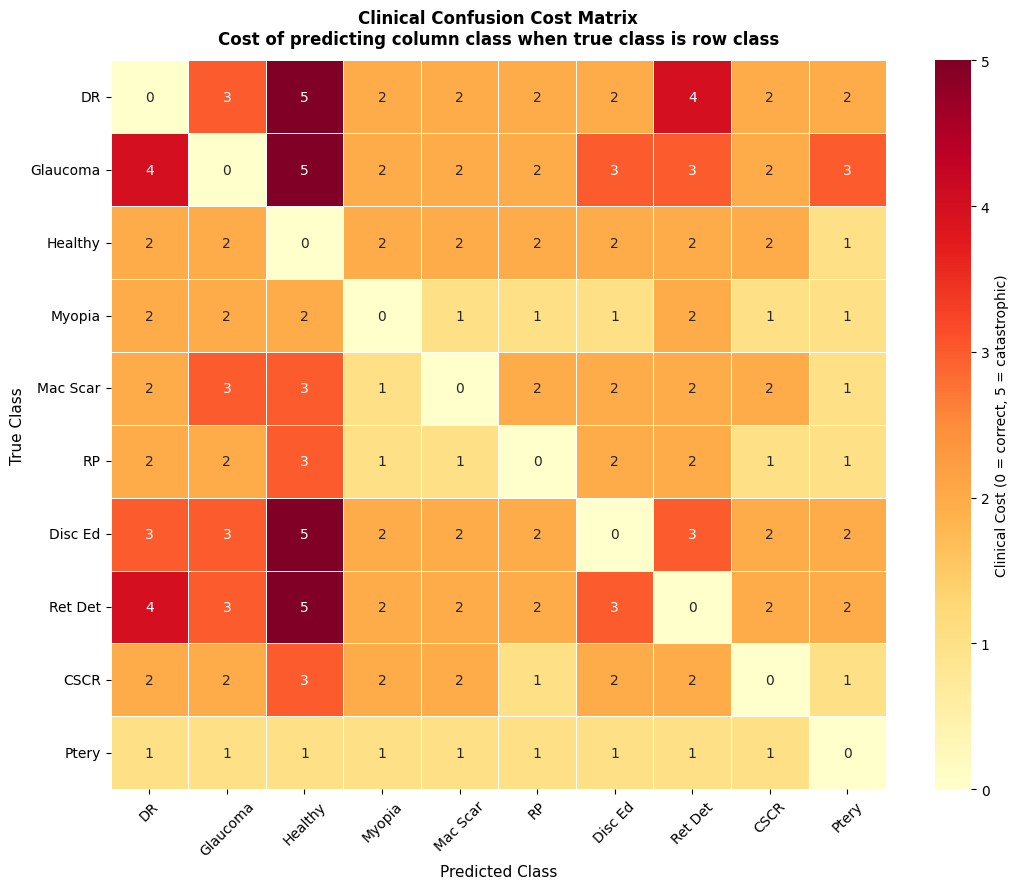

Saved to figures/clinical_cost_matrix.png


In [10]:
# Visualise the cost matrix
fig, ax = plt.subplots(figsize=(11, 9))

sns.heatmap(
    COST,
    annot=True, fmt='.0f',
    cmap='YlOrRd',
    xticklabels=SHORT_NAMES,
    yticklabels=SHORT_NAMES,
    ax=ax,
    linewidths=0.5,
    vmin=0, vmax=5,
    cbar_kws={'label': 'Clinical Cost (0 = correct, 5 = catastrophic)'}
)
ax.set_xlabel('Predicted Class', fontsize=11)
ax.set_ylabel('True Class', fontsize=11)
ax.set_title(
    'Clinical Confusion Cost Matrix\n'
    'Cost of predicting column class when true class is row class',
    fontweight='bold', pad=12
)
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(FIGURES / 'clinical_cost_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to figures/clinical_cost_matrix.png')

---
## 3. Clinical Cost Scoring

In [11]:
# Compute clinical cost score for each run
# Score = sum of (confusion count * clinical cost) across all off-diagonal cells
# Lower is safer

def compute_clinical_cost(confusion_matrix: np.ndarray, cost_matrix: np.ndarray) -> float:
    return float(np.sum(confusion_matrix * cost_matrix))


# Score all runs
scored_results = []

if baseline_results and baseline_results.get('confusion_matrix'):
    cm_b = np.array(baseline_results['confusion_matrix'])
    cost_b = compute_clinical_cost(cm_b, COST)
    baseline_results['clinical_cost'] = cost_b
    scored_results.append({
        'run_name':       'baseline_cnn',
        'architecture':   'Baseline CNN',
        'loss':           'Cross-Entropy',
        'test_acc':       baseline_results['test_acc'],
        'test_macro_f1':  baseline_results['test_macro_f1'],
        'clinical_cost':  round(cost_b, 1),
    })

for run_name, result in all_results.items():
    cm = np.array(result['confusion_matrix'])
    cost = compute_clinical_cost(cm, COST)
    result['clinical_cost'] = cost

    # Save updated result back to Drive
    with open(MODELS_DIR / f'results_{run_name}.json', 'w') as f:
        json.dump(result, f, indent=2)

    arch = 'EfficientNet-B0' if 'efficientnet' in run_name else 'ConvNeXt-Tiny'
    loss = 'Focal' if 'focal' in run_name else 'Weighted CE'
    scored_results.append({
        'run_name':       run_name,
        'architecture':   arch,
        'loss':           loss,
        'test_acc':       result['test_acc'],
        'test_macro_f1':  result['test_macro_f1'],
        'clinical_cost':  round(cost, 1),
    })

df_scored = pd.DataFrame(scored_results).sort_values('clinical_cost')

print('=== FULL RESULTS WITH CLINICAL COST ===')
print(df_scored[['run_name', 'architecture', 'loss', 'test_acc', 'test_macro_f1', 'clinical_cost']].to_string(index=False))
print()
best_cost = df_scored.iloc[0]
print(f'Safest model (lowest clinical cost): {best_cost["run_name"]} ({best_cost["clinical_cost"]})')
best_f1 = df_scored.loc[df_scored['test_macro_f1'].idxmax()]
print(f'Best F1 model                       : {best_f1["run_name"]} ({best_f1["test_macro_f1"]})')

=== FULL RESULTS WITH CLINICAL COST ===
          run_name    architecture          loss  test_acc  test_macro_f1  clinical_cost
  efficientnet_wce EfficientNet-B0   Weighted CE    0.7690         0.7647          377.0
    convnext_focal   ConvNeXt-Tiny         Focal    0.7403         0.7531          414.0
      convnext_wce   ConvNeXt-Tiny   Weighted CE    0.7553         0.7783          421.0
efficientnet_focal EfficientNet-B0         Focal    0.4757         0.5037          850.0
      baseline_cnn    Baseline CNN Cross-Entropy    0.3883         0.4090         1131.0

Safest model (lowest clinical cost): efficientnet_wce (377.0)
Best F1 model                       : convnext_wce (0.7783)


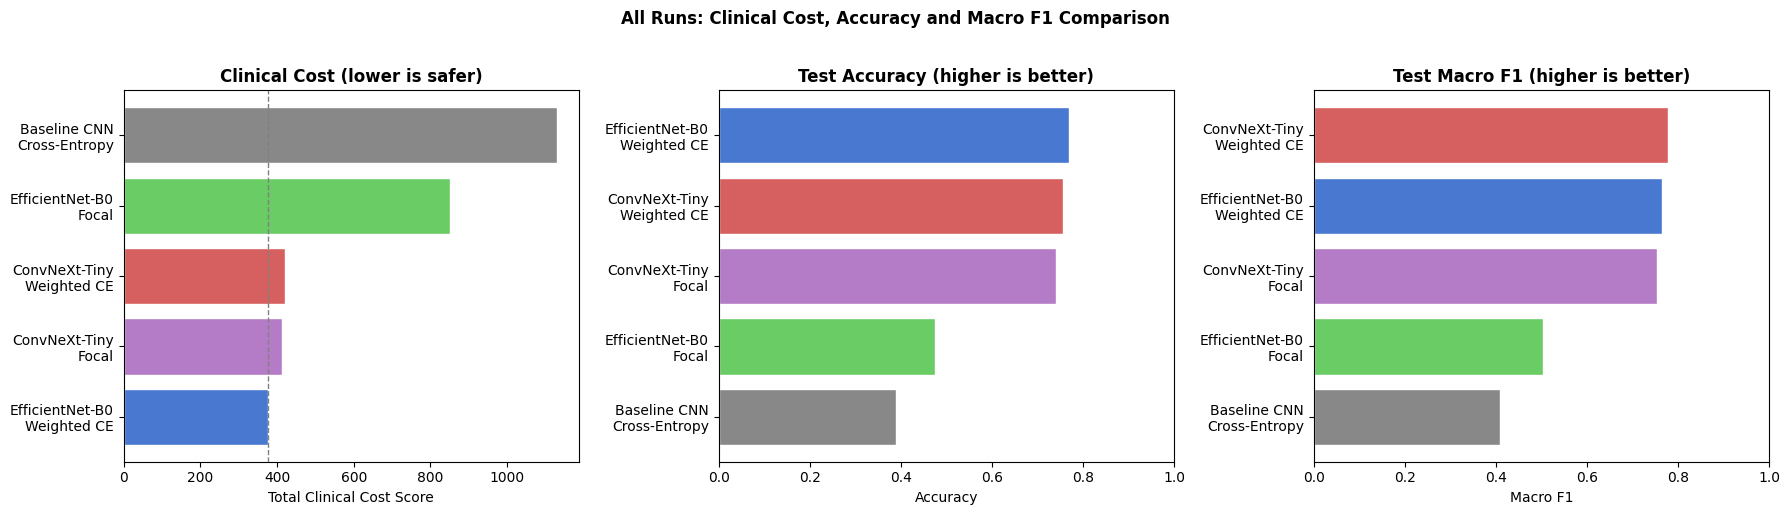

Saved to figures/clinical_cost_comparison.png


In [12]:
# Clinical cost comparison bar chart
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

palette = {
    'baseline_cnn':       '#888888',
    'efficientnet_wce':   '#4878CF',
    'efficientnet_focal': '#6ACC65',
    'convnext_wce':       '#D65F5F',
    'convnext_focal':     '#B47CC7',
}
colours = [palette.get(r, '#333333') for r in df_scored['run_name']]
labels  = [
    f"{row['architecture']}\n{row['loss']}"
    for _, row in df_scored.iterrows()
]

# Clinical cost (lower is better)
axes[0].barh(labels, df_scored['clinical_cost'], color=colours, edgecolor='white')
axes[0].set_title('Clinical Cost (lower is safer)', fontweight='bold')
axes[0].set_xlabel('Total Clinical Cost Score')
axes[0].axvline(df_scored['clinical_cost'].min(), color='grey', linestyle='--', linewidth=1)

# Test accuracy
df_acc = df_scored.sort_values('test_acc', ascending=True)
colours_acc = [palette.get(r, '#333333') for r in df_acc['run_name']]
labels_acc = [f"{row['architecture']}\n{row['loss']}" for _, row in df_acc.iterrows()]
axes[1].barh(labels_acc, df_acc['test_acc'], color=colours_acc, edgecolor='white')
axes[1].set_title('Test Accuracy (higher is better)', fontweight='bold')
axes[1].set_xlabel('Accuracy')
axes[1].set_xlim(0, 1)

# Macro F1
df_f1 = df_scored.sort_values('test_macro_f1', ascending=True)
colours_f1 = [palette.get(r, '#333333') for r in df_f1['run_name']]
labels_f1 = [f"{row['architecture']}\n{row['loss']}" for _, row in df_f1.iterrows()]
axes[2].barh(labels_f1, df_f1['test_macro_f1'], color=colours_f1, edgecolor='white')
axes[2].set_title('Test Macro F1 (higher is better)', fontweight='bold')
axes[2].set_xlabel('Macro F1')
axes[2].set_xlim(0, 1)

plt.suptitle('All Runs: Clinical Cost, Accuracy and Macro F1 Comparison',
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / 'clinical_cost_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to figures/clinical_cost_comparison.png')

---
## 4. Cross-Run Error Pattern Analysis

In [13]:
# Identify confusion pairs that are consistent across all runs
# Consistent confusions point to dataset level issues rather than model issues
# This directly informs the Limitations and Error Analysis sections of the report

# Collect off-diagonal confusion counts for each run
confusion_records = []
for run_name, result in all_results.items():
    cm = np.array(result['confusion_matrix'])
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            if i != j and cm[i, j] > 0:
                confusion_records.append({
                    'run':        run_name,
                    'true':       CLASS_NAMES[i],
                    'predicted':  CLASS_NAMES[j],
                    'count':      int(cm[i, j]),
                    'cost':       COST[i, j],
                    'true_idx':   i,
                    'pred_idx':   j,
                })

df_confusions = pd.DataFrame(confusion_records)

# Find pairs appearing in all 4 runs
pair_run_counts = (
    df_confusions.groupby(['true', 'predicted'])['run']
    .nunique()
    .reset_index()
    .rename(columns={'run': 'runs_with_confusion'})
)
consistent_pairs = pair_run_counts[pair_run_counts['runs_with_confusion'] == 4].copy()

# Add average count and cost
avg_counts = (
    df_confusions.groupby(['true', 'predicted'])['count']
    .mean()
    .reset_index()
    .rename(columns={'count': 'avg_count'})
)
consistent_pairs = consistent_pairs.merge(avg_counts, on=['true', 'predicted'])
consistent_pairs = consistent_pairs.merge(
    df_confusions[['true', 'predicted', 'cost']].drop_duplicates(),
    on=['true', 'predicted']
)
consistent_pairs = consistent_pairs.sort_values(
    ['cost', 'avg_count'], ascending=[False, False]
)

print('Confusion pairs appearing in ALL 4 runs (dataset level patterns):')
print(consistent_pairs[['true', 'predicted', 'avg_count', 'cost']].to_string(index=False))
print()
print('These confusions persist regardless of architecture or loss function.')
print('They are candidates for dataset bias, imaging artefacts, or class overlap.')

Confusion pairs appearing in ALL 4 runs (dataset level patterns):
                            true                        predicted  avg_count  cost
            Diabetic Retinopathy                          Healthy       6.50   5.0
                        Glaucoma                        Pterygium      36.00   3.0
                    Macular Scar                         Glaucoma      11.75   3.0
            Diabetic Retinopathy                         Glaucoma       1.75   3.0
                        Glaucoma                     Macular Scar      42.25   2.0
            Diabetic Retinopathy                           Myopia      11.75   2.0
            Diabetic Retinopathy             Retinitis Pigmentosa       8.75   2.0
                        Glaucoma                           Myopia       7.75   2.0
            Diabetic Retinopathy Central Serous Chorioretinopathy       5.00   2.0
                          Myopia                         Glaucoma       4.75   2.0
Central Serous Chorio

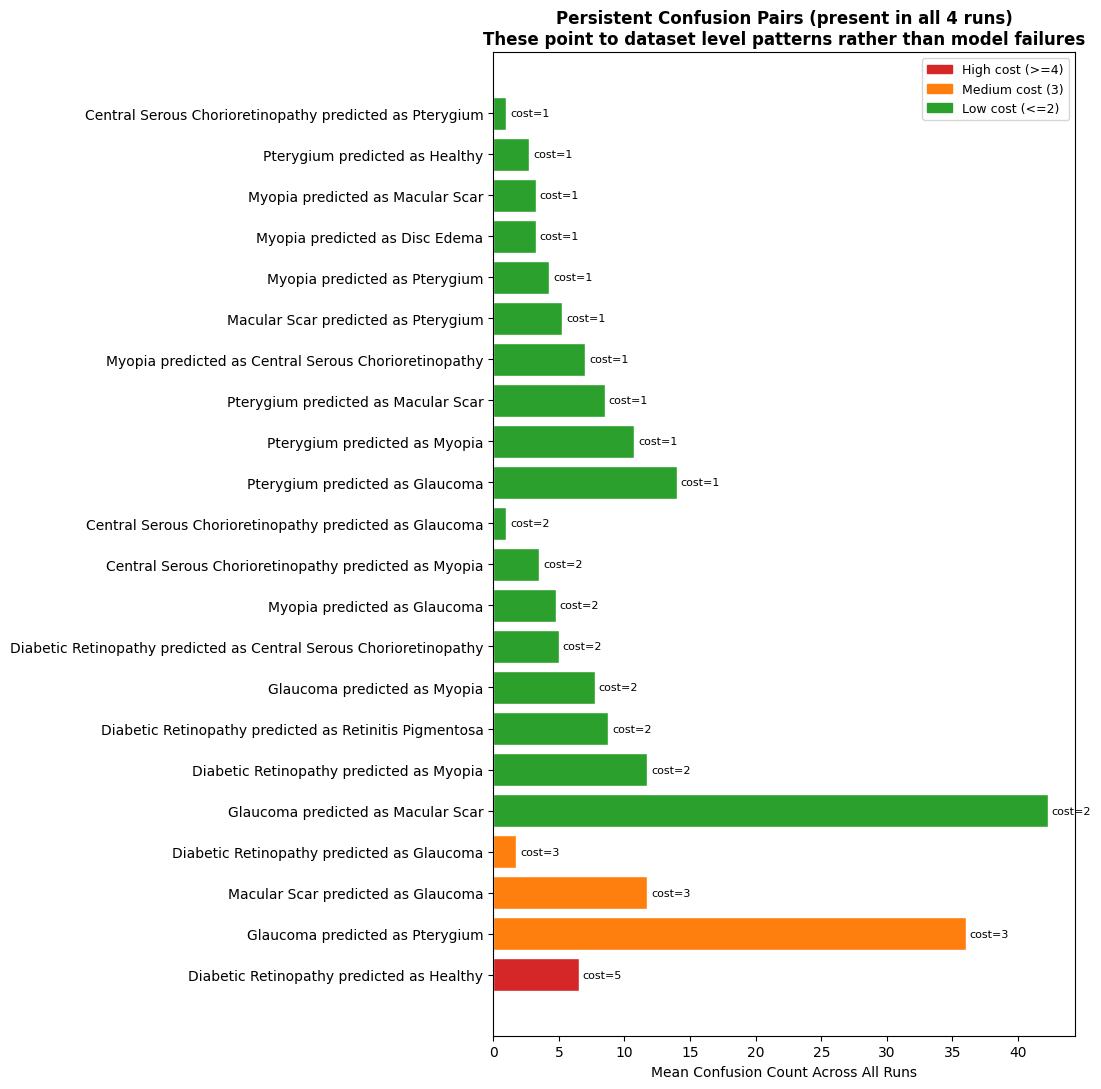

Saved to figures/consistent_confusions.png


In [14]:
# Visualise consistent confusion pairs by clinical cost
if len(consistent_pairs) > 0:
    fig, ax = plt.subplots(figsize=(11, max(4, len(consistent_pairs) * 0.5)))

    pair_labels = [
        f"{row['true']} predicted as {row['predicted']}"
        for _, row in consistent_pairs.iterrows()
    ]
    bar_colours = [
        '#d62728' if c >= 4 else '#ff7f0e' if c >= 3 else '#2ca02c'
        for c in consistent_pairs['cost']
    ]

    bars = ax.barh(pair_labels, consistent_pairs['avg_count'],
                   color=bar_colours, edgecolor='white')

    for bar, cost in zip(bars, consistent_pairs['cost']):
        ax.text(
            bar.get_width() + 0.3,
            bar.get_y() + bar.get_height() / 2,
            f'cost={int(cost)}',
            va='center', fontsize=8
        )

    high   = mpatches.Patch(color='#d62728', label='High cost (>=4)')
    medium = mpatches.Patch(color='#ff7f0e', label='Medium cost (3)')
    low    = mpatches.Patch(color='#2ca02c', label='Low cost (<=2)')
    ax.legend(handles=[high, medium, low], fontsize=9)

    ax.set_xlabel('Mean Confusion Count Across All Runs')
    ax.set_title(
        'Persistent Confusion Pairs (present in all 4 runs)\n'
        'These point to dataset level patterns rather than model failures',
        fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig(FIGURES / 'consistent_confusions.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved to figures/consistent_confusions.png')
else:
    print('No confusion pairs found across all 4 runs.')

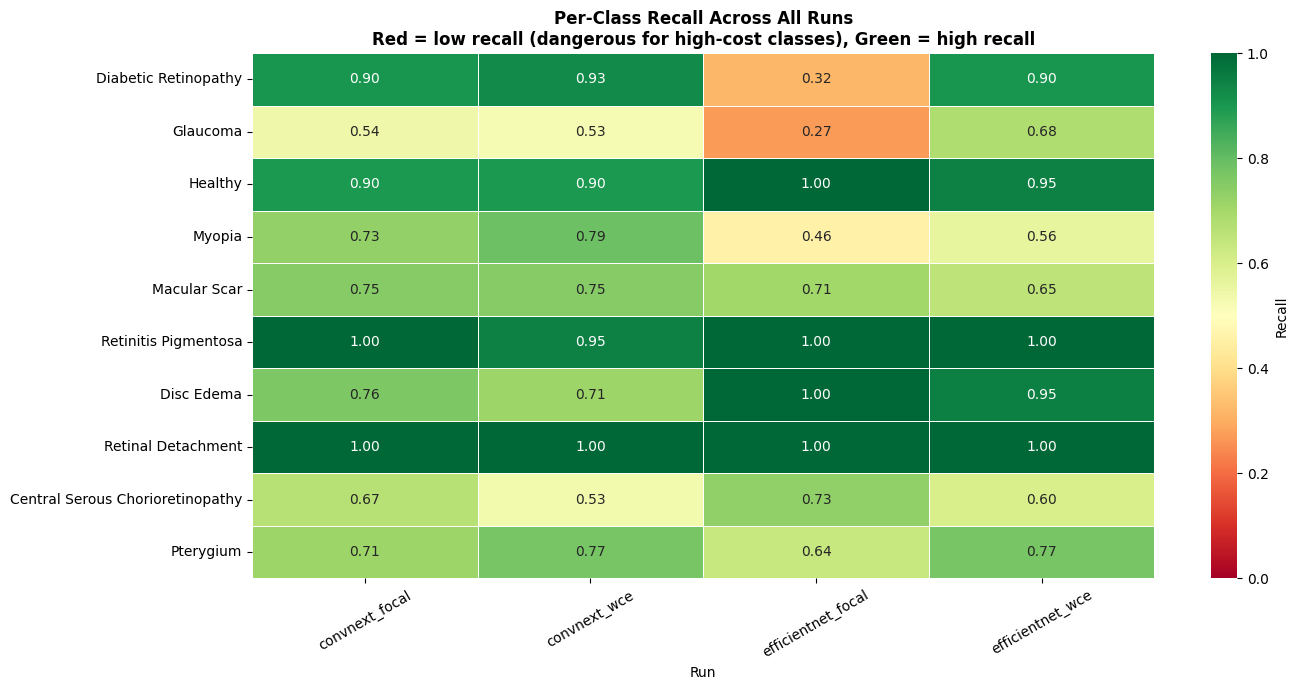

Saved to figures/per_class_recall_comparison.png


In [15]:
# Per-class recall comparison across all runs
# Shows which classes benefit from which architecture or loss function

recall_records = []
for run_name, result in all_results.items():
    cm = np.array(result['confusion_matrix'])
    row_sums = cm.sum(axis=1)
    for i in range(NUM_CLASSES):
        recall = cm[i, i] / row_sums[i] if row_sums[i] > 0 else 0
        recall_records.append({
            'run':       run_name,
            'class':     CLASS_NAMES[i],
            'recall':    round(recall, 3),
        })

df_recall = pd.DataFrame(recall_records)
df_recall_pivot = df_recall.pivot(index='class', columns='run', values='recall')
df_recall_pivot = df_recall_pivot.reindex(CLASS_NAMES)

fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(
    df_recall_pivot,
    annot=True, fmt='.2f',
    cmap='RdYlGn',
    vmin=0, vmax=1,
    ax=ax,
    linewidths=0.5,
    cbar_kws={'label': 'Recall'}
)
ax.set_title(
    'Per-Class Recall Across All Runs\n'
    'Red = low recall (dangerous for high-cost classes), Green = high recall',
    fontweight='bold'
)
ax.set_xlabel('Run')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(FIGURES / 'per_class_recall_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to figures/per_class_recall_comparison.png')

---
## 5. Failure Case Review (Best Model)

In [16]:
# Load best model for inference on failure cases
def preprocess_fundus(img_path, img_size=224):
    img = cv2.imread(str(img_path))
    if img is None:
        raise ValueError(f'Cannot read: {img_path}')
    _, green, _ = cv2.split(img)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    green_clahe = clahe.apply(green)
    img_3ch = cv2.merge([green_clahe, green_clahe, green_clahe])
    return cv2.resize(img_3ch, (img_size, img_size), interpolation=cv2.INTER_LINEAR)


IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]
eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class RetinalDataset(Dataset):
    def __init__(self, paths, labels, transform=None):
        self.paths = paths; self.labels = labels; self.transform = transform
    def __len__(self): return len(self.paths)
    def __getitem__(self, idx):
        img = Image.fromarray(preprocess_fundus(self.paths[idx]))
        if self.transform: img = self.transform(img)
        return img, torch.tensor(self.labels[idx], dtype=torch.long)


test_loader = DataLoader(
    RetinalDataset(test_paths, test_labels, eval_transform),
    batch_size=32, shuffle=False, num_workers=2
)

# Load best model
best_ckpt_path = MODELS_DIR / f'{BEST_RUN}_best.pth'
assert best_ckpt_path.exists(), f'Checkpoint not found: {best_ckpt_path}'

best_model = timm.create_model('convnext_tiny', pretrained=False, num_classes=NUM_CLASSES)
ckpt = torch.load(best_ckpt_path, map_location=DEVICE)
best_model.load_state_dict(ckpt['model_state_dict'])
best_model = best_model.to(DEVICE).eval()
print(f'Loaded {BEST_RUN} (val F1={ckpt["val_f1"]:.4f})')

Loaded convnext_wce (val F1=0.7850)


In [20]:
# Run inference on test set to get predictions and confidence scores
@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()
    all_preds, all_probs = [], []
    for imgs, _ in tqdm(loader, desc='Predicting', leave=False):
        imgs = imgs.to(device)
        probs = torch.softmax(model(imgs), dim=1)
        all_preds.extend(probs.argmax(1).cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    return np.array(all_preds), np.array(all_probs)

best_preds, best_probs = get_predictions(best_model, test_loader, DEVICE)

# Identify high-cost misclassifications
failure_records = []
for idx in range(len(test_paths)):
    true_idx = test_labels[idx]
    pred_idx = best_preds[idx]
    if true_idx != pred_idx:
        cost = COST[true_idx, pred_idx]
        confidence = best_probs[idx, pred_idx]
        failure_records.append({
            'path':       test_paths[idx],
            'true':       CLASS_NAMES[true_idx],
            'predicted':  CLASS_NAMES[pred_idx],
            'cost':       cost,
            'confidence': round(float(confidence), 3),
            'true_idx':   true_idx,
            'pred_idx':   pred_idx,
        })

df_failures = pd.DataFrame(failure_records).sort_values(
    ['cost', 'confidence'], ascending=[False, False]
)
print(f'Total misclassifications: {len(df_failures)}')
print(f'High cost errors (cost >= 4): {(df_failures["cost"] >= 4).sum()}')
print()
print('Top 10 highest-cost misclassifications:')
print(df_failures[['true', 'predicted', 'cost', 'confidence']].head(10).to_string(index=False))

Total misclassifications: 196
High cost errors (cost >= 4): 6

Top 10 highest-cost misclassifications:
                true            predicted  cost  confidence
Diabetic Retinopathy              Healthy   5.0       0.999
Diabetic Retinopathy              Healthy   5.0       0.998
Diabetic Retinopathy              Healthy   5.0       0.996
            Glaucoma Diabetic Retinopathy   4.0       0.994
            Glaucoma Diabetic Retinopathy   4.0       0.572
            Glaucoma Diabetic Retinopathy   4.0       0.549
            Glaucoma            Pterygium   3.0       0.945
            Glaucoma            Pterygium   3.0       0.937
            Glaucoma            Pterygium   3.0       0.926
            Glaucoma            Pterygium   3.0       0.926


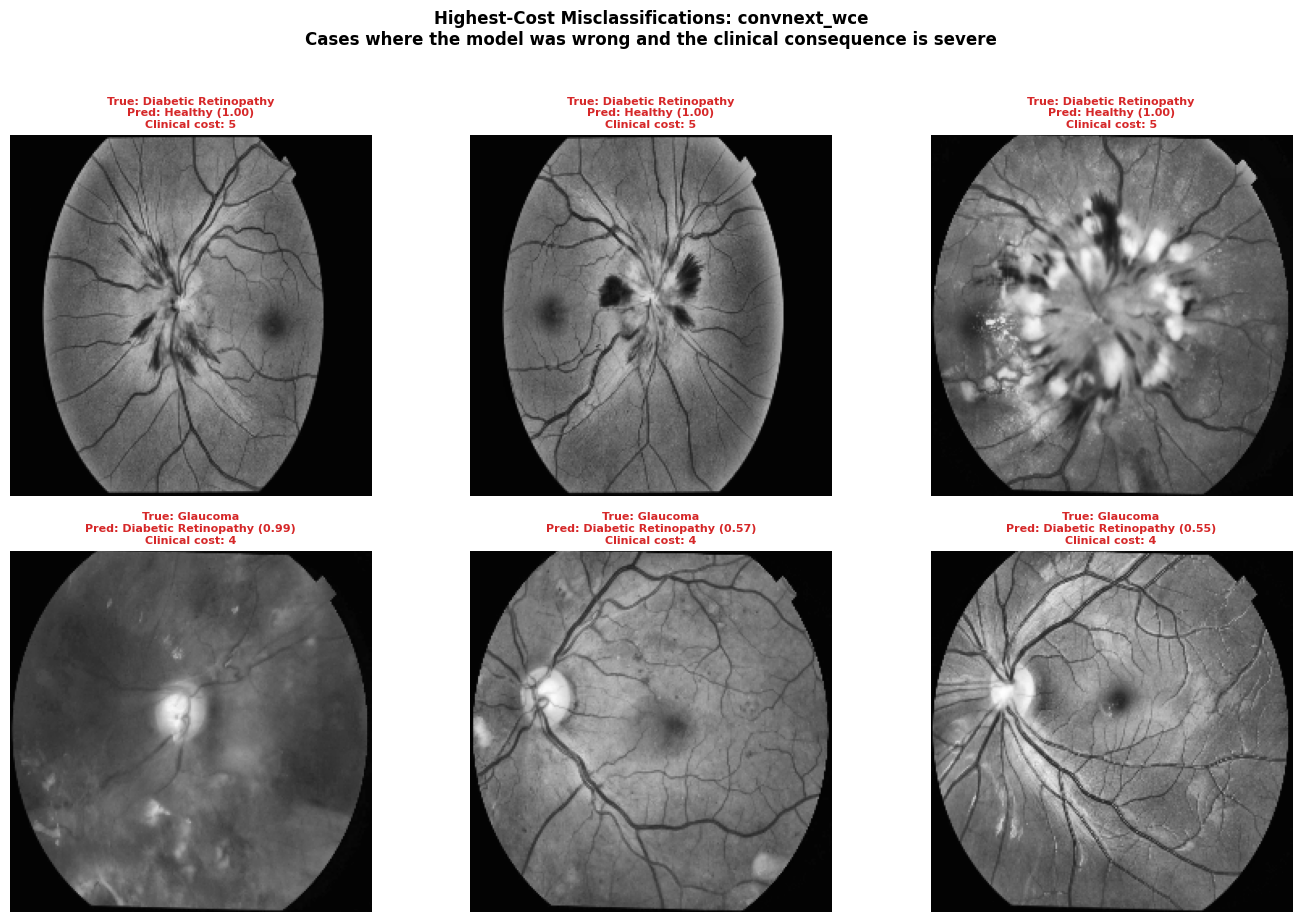

Saved to figures/worst_failure_cases.png


In [21]:
# Visualise the worst failure cases
# Show images where clinical cost is highest and model was most confident
N_SHOW = min(6, len(df_failures[df_failures['cost'] >= 4]))

if N_SHOW == 0:
    print('No high-cost misclassifications found.')
else:
    worst = df_failures[df_failures['cost'] >= 4].head(N_SHOW)
    fig, axes = plt.subplots(2, 3, figsize=(14, 9))
    axes = axes.flatten()

    for ax_idx, (_, row) in enumerate(worst.iterrows()):
        if ax_idx >= len(axes):
            break
        img = preprocess_fundus(row['path'])
        axes[ax_idx].imshow(img, cmap='gray')
        axes[ax_idx].set_title(
            f'True: {row["true"]}\n'
            f'Pred: {row["predicted"]} ({row["confidence"]:.2f})\n'
            f'Clinical cost: {int(row["cost"])}',
            fontsize=8, color='#d62728', fontweight='bold'
        )
        axes[ax_idx].axis('off')

    for ax in axes[N_SHOW:]:
        ax.set_visible(False)

    plt.suptitle(
        f'Highest-Cost Misclassifications: {BEST_RUN}\n'
        'Cases where the model was wrong and the clinical consequence is severe',
        fontweight='bold', y=1.02
    )
    plt.tight_layout()
    plt.savefig(FIGURES / 'worst_failure_cases.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved to figures/worst_failure_cases.png')

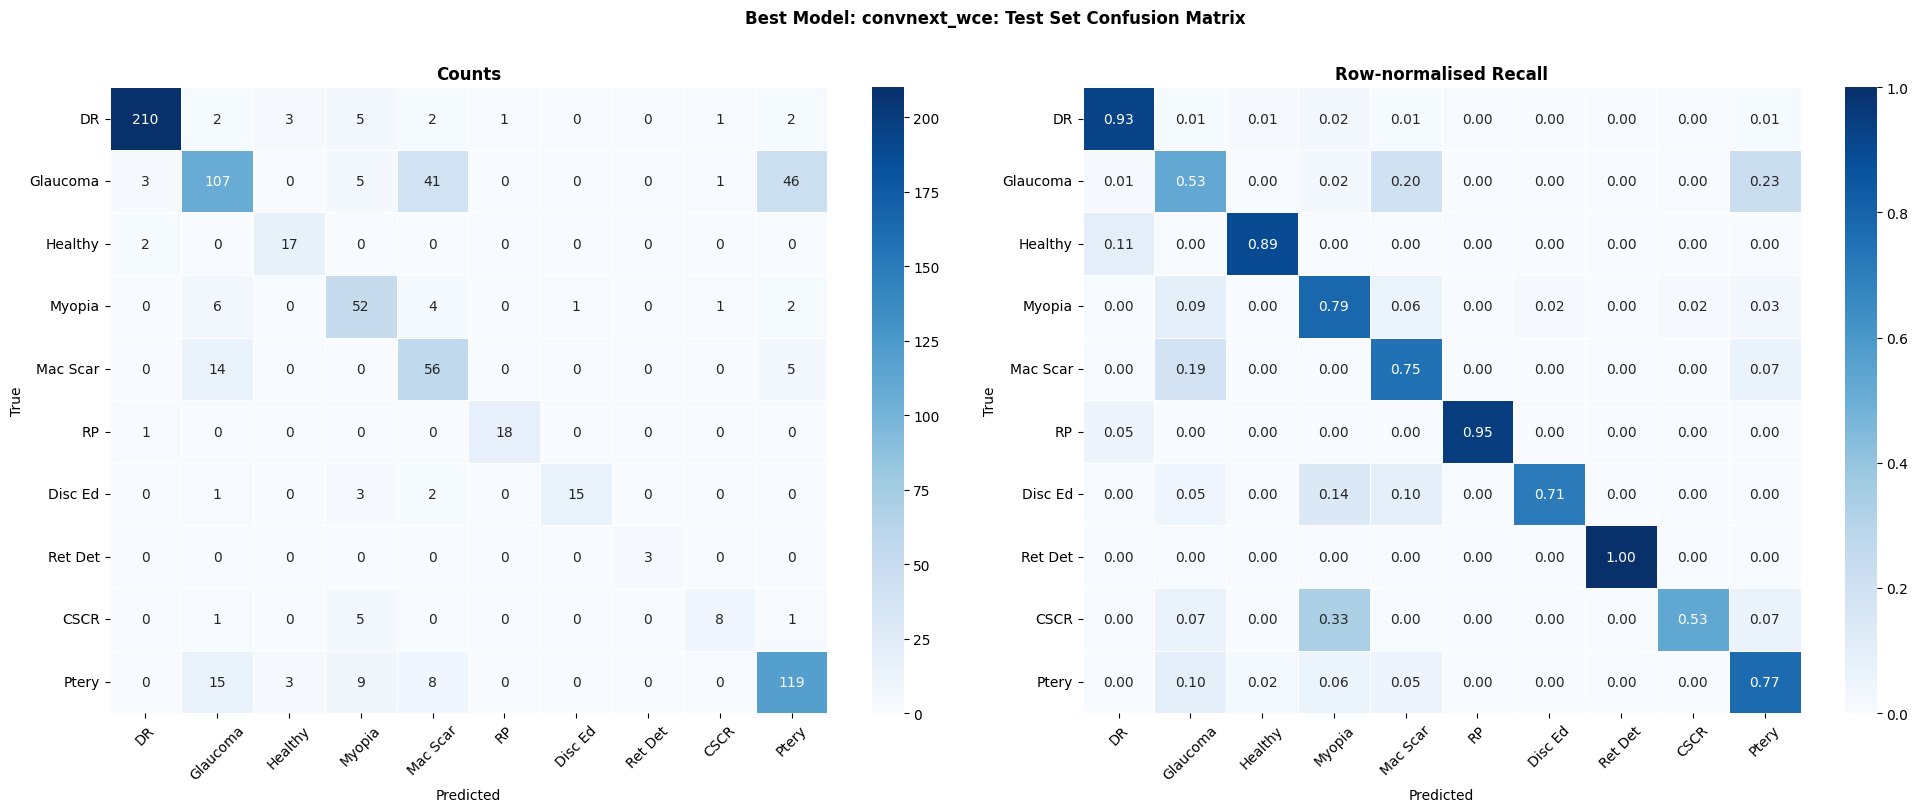

Saved to figures/confusion_matrix_best.png


In [22]:
# Best model confusion matrix (final, definitive version)
cm_best = np.array(all_results[BEST_RUN]['confusion_matrix'])
cm_norm = cm_best.astype(float) / cm_best.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(
    cm_best, annot=True, fmt='d', cmap='Blues',
    xticklabels=SHORT_NAMES, yticklabels=SHORT_NAMES,
    ax=axes[0], linewidths=0.4
)
axes[0].set_title('Counts', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=SHORT_NAMES, yticklabels=SHORT_NAMES,
    ax=axes[1], linewidths=0.4, vmin=0, vmax=1
)
axes[1].set_title('Row-normalised Recall', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle(
    f'Best Model: {BEST_RUN}: Test Set Confusion Matrix',
    fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig(FIGURES / 'confusion_matrix_best.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to figures/confusion_matrix_best.png')

---
## 6. Final Results Table

In [23]:
# Print final results table
print('=' * 75)
print('FINAL RESULTS TABLE')
print('=' * 75)
print(f'{"Model":<25} {"Loss":<14} {"Acc":>8} {"Macro F1":>10} {"Clin Cost":>11}')
print('-' * 75)

for _, row in df_scored.iterrows():
    marker = ' <-- best F1' if row['run_name'] == BEST_RUN else ''
    print(
        f"{row['architecture']:<25} "
        f"{row['loss']:<14} "
        f"{row['test_acc']:>8.4f} "
        f"{row['test_macro_f1']:>10.4f} "
        f"{row['clinical_cost']:>11.1f}"
        f"{marker}"
    )

print('=' * 75)
print()
print('Classification report for best model:')
print(classification_report(
    test_labels,
    best_preds,
    target_names=CLASS_NAMES,
    zero_division=0
))
print()
print('Key findings for report:')
print(f'  Best model by Macro F1    : {BEST_RUN}')
print(f'  Best model by safety      : {df_scored.iloc[0]["run_name"]}')
print(f'  Focal Loss underperformed : EfficientNet Focal F1={all_results["efficientnet_focal"]["test_macro_f1"]:.4f}')
print(f'  WCE consistently better   : across both architectures on this dataset')

# Flag if best F1 model and safest model differ
if BEST_RUN != df_scored.iloc[0]['run_name']:
    print()
    print(f'NOTE: Best F1 model ({BEST_RUN}) and safest model '
          f'({df_scored.iloc[0]["run_name"]}) differ.')

FINAL RESULTS TABLE
Model                     Loss                Acc   Macro F1   Clin Cost
---------------------------------------------------------------------------
EfficientNet-B0           Weighted CE      0.7690     0.7647       377.0
ConvNeXt-Tiny             Focal            0.7403     0.7531       414.0
ConvNeXt-Tiny             Weighted CE      0.7553     0.7783       421.0 <-- best F1
EfficientNet-B0           Focal            0.4757     0.5037       850.0
Baseline CNN              Cross-Entropy    0.3883     0.4090      1131.0

Classification report for best model:
                                  precision    recall  f1-score   support

            Diabetic Retinopathy       0.97      0.93      0.95       226
                        Glaucoma       0.73      0.53      0.61       203
                         Healthy       0.74      0.89      0.81        19
                          Myopia       0.66      0.79      0.72        66
                    Macular Scar       0.50 

In [24]:
!git status -v

On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	figures/clinical_cost_comparison.png
	figures/clinical_cost_matrix.png
	figures/confusion_matrix_best.png
	figures/consistent_confusions.png
	figures/per_class_recall_comparison.png
	figures/worst_failure_cases.png

nothing added to commit but untracked files present (use "git add" to track)


---
## 7. Commit and Push

In [25]:
NB_SRC  = Path('/content/drive/MyDrive/Colab Notebooks/05_Error_Analysis.ipynb')
NB_DEST = REPO_DIR / 'notebooks' / '05_Error_Analysis.ipynb'
NB_DEST.parent.mkdir(parents=True, exist_ok=True)

if NB_SRC.exists():
    shutil.copy(NB_SRC, NB_DEST)
    print(f'Copied to {NB_DEST}')

assert NB_DEST.exists(), f'Copy failed: {NB_DEST} not found'

%cd {REPO_DIR}
!git add figures/
!git status
!git commit -m "Commiting updated 05_Error_Analysis notebook"
!git push
print('Done. Notebook 05 committed and pushed.')

Copied to /content/retinal-disease-classification/notebooks/05_Error_Analysis.ipynb
/content/retinal-disease-classification
On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   figures/clinical_cost_comparison.png
	new file:   figures/clinical_cost_matrix.png
	new file:   figures/confusion_matrix_best.png
	new file:   figures/consistent_confusions.png
	new file:   figures/per_class_recall_comparison.png
	new file:   figures/worst_failure_cases.png

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   notebooks/05_Error_Analysis.ipynb

[main 723fff3] Commiting untracked figures from this notebook
 6 files changed, 0 insertions(+), 0 deletions(-)
 create mode 100644 figures/clinical_cost_comparison.png
 create mode 100644 figures/clinical_cost_matrix.png
 create mode 1